In [ ]:
pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import matplotlib.pyplot as plt

In [ ]:
#Load Data
df = pd.read_csv(r"C:\Working\ML_Project\telecom_traffic_1yr_200cells.csv.gz")
print(df.head())

In [ ]:
print(df.shape)
print(df.columns)
print(df.describe())

In [ ]:
df.keys ()

In [ ]:
#Convert Date to Datetime

df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df.head ()

In [ ]:
#Sort Data

df = df.sort_values(['Date','Cell_ID'])

In [ ]:
#Create Lag Features

df['lag_1'] = df.groupby('Cell_ID')['DL_Volume_GB'].shift(1)
df['lag_24'] = df.groupby('Cell_ID')['DL_Volume_GB'].shift(24)
df['lag_168'] = df.groupby('Cell_ID')['DL_Volume_GB'].shift(168)

In [ ]:
print(df['lag_1'])

In [ ]:
#Rolling Average Features

df['rolling_mean_24'] = df.groupby('Cell_ID')['DL_Volume_GB'].transform(lambda x: x.rolling(24).mean())

df['rolling_mean_168'] = df.groupby('Cell_ID')['DL_Volume_GB'].transform(lambda x: x.rolling(168).mean())

In [ ]:
#Extract Time Features

df['hour'] = df['Date'].dt.hour
df['day_of_week'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month

In [ ]:
df = df.dropna()
print(df.head())
print(df.shape)

In [ ]:
df.to_csv(r"C:\Working\ML_Project\telecom_feature_engineered.csv",index=False)

In [ ]:
df = pd.read_csv(r"C:\Working\ML_Project\telecom_feature_engineered.csv")

print(df.head())

In [ ]:
target = 'DL_Volume_GB'

features = [
'lag_1',
'lag_24',
'lag_168',
'rolling_mean_24',
'rolling_mean_168',
'PRB_Util',
'Active_Users',
'Weekend',
'Event_Flag',
'hour',
'day_of_week',
'month'
]

X = df[features]
y = df[target]

In [ ]:
#Train-Test Split

train_size = int(len(df)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [ ]:
from sklearn.linear_model import LinearRegression 

In [ ]:
#Train XGBoost Model
model = xgb.XGBRegressor(
n_estimators=200,
learning_rate=0.05,
max_depth=6,
subsample=0.8,
colsample_bytree=0.8,
random_state=42
)

model.fit(X_train,y_train)

In [ ]:
#Make Prediction

y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

print("MAE:",mae)
print("RMSE:",rmse)

In [ ]:
#Plot Actual vs Predicted

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200],label="Actual")
plt.plot(y_pred[:200],label="Predicted")

plt.legend()
plt.title("Traffic Forecasting")

plt.show()


In [ ]:
#Feature Importance
importance = model.feature_importances_

feature_imp = pd.DataFrame({
'Feature':features,
'Importance':importance
})

feature_imp = feature_imp.sort_values(by='Importance',ascending=False)

print(feature_imp)

In [ ]:
plt.barh(feature_imp['Feature'],feature_imp['Importance'])
plt.title("Feature Importance")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
models = {

"Linear Regression": LinearRegression(),

"Random Forest": RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
),

"XGBoost": xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

}

In [ ]:
results = []

for name, model in models.items():

    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    mape = np.mean(np.abs((y_test-y_pred)/y_test))*100

    results.append({
        "Model":name,
        "MAE":mae,
        "RMSE":rmse,
        "MAPE":mape
    })

results_df = pd.DataFrame(results)

print(results_df)

In [ ]:
print(results_df)

In [ ]:
results_df.set_index("Model")[["MAE","RMSE"]].plot(kind="bar",figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Error Value")

plt.show()

In [ ]:
best_model = results_df.sort_values("RMSE").iloc[0]

print("Best Model:")
print(best_model)

In [ ]:
#Get Feature Importance from the Model

# Extract importance
importance = model.feature_importances_

feature_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# Sort by importance
feature_imp = feature_imp.sort_values(by='Importance', ascending=False)

print(feature_imp)

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(feature_imp['Feature'], feature_imp['Importance'])

plt.xlabel("Importance Score")
plt.title("Feature Importance for Traffic Forecasting")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
df['Congestion'] = (df['PRB_Util'] > 80).astype(int)

In [48]:
features = [
'lag_1','lag_24','lag_168','rolling_mean_24','rolling_mean_168',
'DL_Volume_GB','Active_Users','Weekend','Event_Flag','hour','day_of_week'
]

X = df[features]
y = df['Congestion']

In [ ]:
train_size = int(len(df)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
n_estimators=100,
max_depth=10,
random_state=42
)

rf.fit(X_train,y_train)

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
n_estimators=200,
learning_rate=0.05,
max_depth=6,
subsample=0.8,
colsample_bytree=0.8
)

xgb_model.fit(X_train,y_train)

In [ ]:
#Evaluate Model

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

In [ ]:
y_pred = xgb_model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print("ROC AUC:",roc_auc_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

In [ ]:
#Predict congestion probability

prob = xgb_model.predict_proba(X_test)[:,1]

In [ ]:
print(prob)

In [ ]:
importance = model.feature_importances_

feature_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

feature_imp = feature_imp.sort_values(by='Importance', ascending=False)

print(feature_imp)

In [ ]:
print(len(features))
print(len(model.feature_importances_))

In [ ]:

plt.figure(figsize=(10,6))

plt.barh(feature_imp['Feature'], feature_imp['Importance'])

plt.xlabel("Importance Score")
plt.title("Feature Importance - Telecom Traffic Forecasting")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
pip install joblib

In [49]:
import joblib


joblib.dump(model, "traffic_forecasting_model.pkl")
joblib.dump(xgb_model, "congestion_prediction_model.pkl")


['congestion_prediction_model.pkl']

In [47]:
!jupyter nbconvert --to script "Ml project.ipynb"

[NbConvertApp] Converting notebook Ml project.ipynb to script
[NbConvertApp] Writing 6984 bytes to Ml project.py


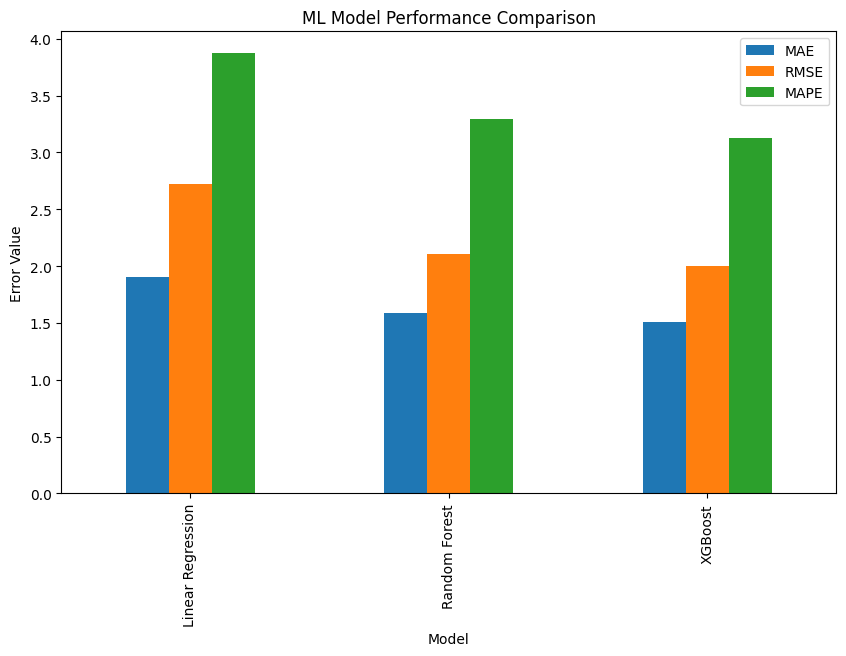

In [50]:
results_df.set_index("Model")[["MAE","RMSE","MAPE"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("ML Model Performance Comparison")
plt.ylabel("Error Value")
plt.show()

In [51]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)

print("R2 Score:", r2)

R2 Score: 0.9907589859167231


In [52]:
!jupyter nbconvert --to script "Ml project.ipynb"


[NbConvertApp] Converting notebook Ml project.ipynb to script
[NbConvertApp] Writing 7058 bytes to Ml project.py
